# Intro to superpixels
Quick presentation of most known superpixel generation methods along with short explanation.

Most of the notes are based on this article from skiimage docx: https://scikit-image.org/docs/stable/auto_examples/segmentation/plot_segmentations.html

In [17]:
# Imports
import os
import PIL.Image
import numpy as np
import matplotlib.pyplot as plt
from skimage.segmentation import mark_boundaries



## Sample data

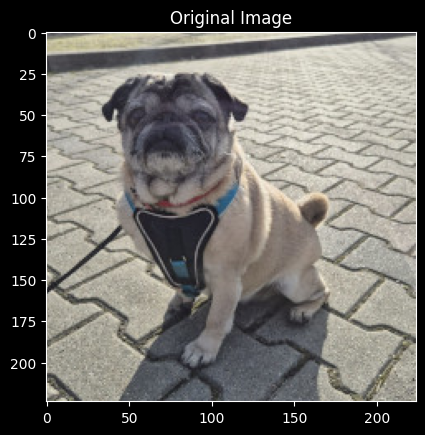

In [18]:
path = os.path.join('assets', 'MyPug.jpg')
img = np.array(PIL.Image.open(path))

plt.imshow(img)
plt.title('Original Image')
plt.show()

# Squares Mask
Mostly used as reference, simple idea of splitting image into squares.

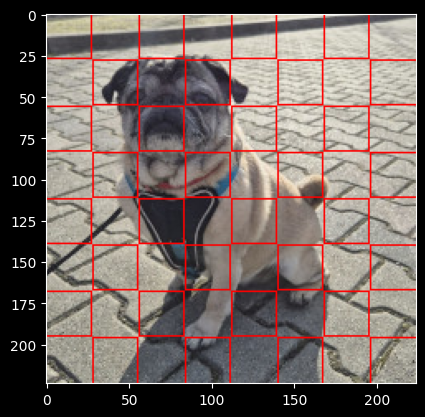

In [29]:
from skimage.segmentation import checkerboard_level_set

sq_mask = checkerboard_level_set(img.shape[0:2], square_size=28)
sq_img = mark_boundaries(img, sq_mask,color=(1,0,0))

plt.imshow(sq_img)
plt.title('Square Superpixels Mask')
plt.show()

# SLIC (Simple Linear Iterative Clustering)
This algorithm simply performs K-means in the 5d space of color information and image location and is therefore closely related to quickshift (Later).

Read more: https://ieeexplore.ieee.org/abstract/document/6205760?casa_token=ozvO8039WVQAAAAA:mzzSf1k8Anv0vusD8hIMHW0pq7wQgEWQpOIiyHwwW147iBq0KbWZON11kpmMEAuYWIJSwY9_lwo

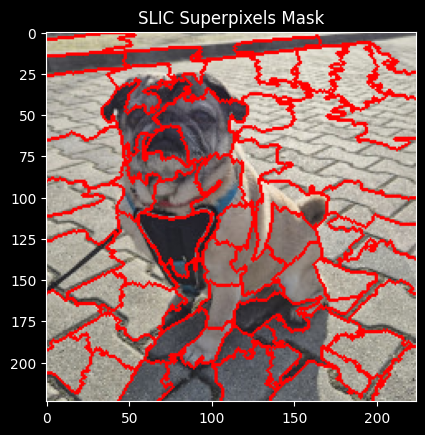

In [41]:
from skimage.segmentation import slic
slic_mask = slic(img)
slic_img = mark_boundaries(img/255, slic_mask, color=(1,0,0))
plt.imshow(slic_img)
plt.title('SLIC Superpixels Mask')
plt.show()

# Quick Shift
The algorithm is based in kernelized mean-shift approximation.
It belongs to the family of local mode-seeking algorithms and is applied to the 5D space consisting of color information and image location.
Simply it creates clusters of neighborhood pixels based on their similarity.

Read More: https://link.springer.com/chapter/10.1007/978-3-540-88693-8_52

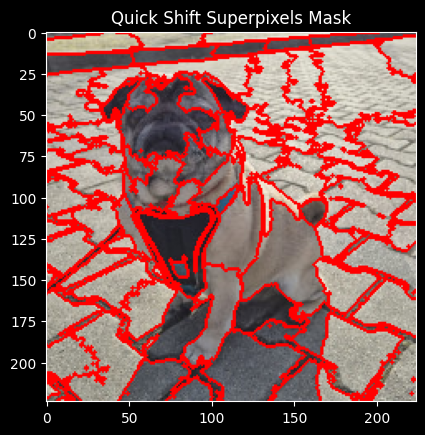

In [30]:
from skimage.segmentation import quickshift
qs_mask = quickshift(img)
qs_img = mark_boundaries(img/255.0, qs_mask, color=(1,0,0))
plt.imshow(qs_img)
plt.title('Quick Shift Superpixels Mask')
plt.show()

# Felzenszwalb’s algorithm
Graph based algorithm. First, it creates centers of clusters based on `size` parameter, then it assigns pixel to the nearest (in terms of color and location) cluster center.

Read More: https://link.springer.com/article/10.1023/B:VISI.0000022288.19776.77

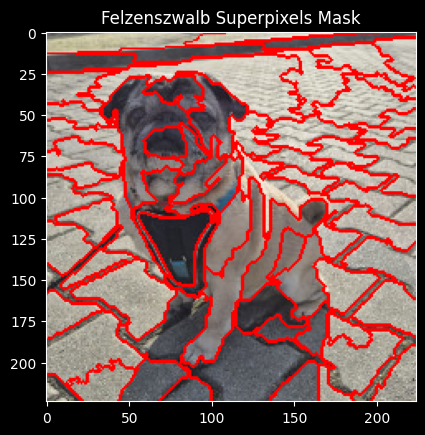

In [50]:
from skimage.segmentation import felzenszwalb
flb_mask = felzenszwalb(img, min_size=14*14)
flb_img = mark_boundaries(img/255, flb_mask, color=(1,0,0))
plt.imshow(flb_img)
plt.title('Felzenszwalb Superpixels Mask')
plt.show()